In [5]:
import sys
sys.path.append("source/data_processing")
sys.path.append("source/utils")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from add_times import add_times
from drop_duplicate import corriger_doublons
from moyenne_horaire import lisser_en_horaire
from encodage_pred_prod import standardize_pred_prod_rolling
from encodage_wind import standardize_wind
from encodage_prix import standardize_prices_rolling
from prepare_dataset import prepare_dataset
from get_pred_df_inverted import get_pred_df_inverted
from performance_metric import eval_all
from source import price_models

df = pd.read_csv("data/raw/data_raw.csv")
df_prod = pd.read_csv("data/raw/prediction_production/production_entsoe_pred.csv")
df_wind = pd.read_csv("data/raw/vent/wind_entsoe_pred.csv")

df = add_times(df)

df_prod["date"] = pd.to_datetime(df_prod["date"])
df_wind["date"] = pd.to_datetime(df_wind["date"])

df = df.reset_index()  # remet date_paris en colonne pour le merge
df["_merge_key"] = df["date_paris"].dt.tz_localize(None)
df = df.merge(df_prod, left_on="_merge_key", right_on="date", how="left")
df = df.merge(df_wind, left_on="_merge_key", right_on="date", how="left", suffixes=("", "_wind"))
df = df.drop(columns=["_merge_key"])


df = corriger_doublons(df)
df = lisser_en_horaire(df)
df = standardize_pred_prod_rolling(df, window_days=30, pred_col='Day-ahead Total Load Forecast (MW)', time_col='date_paris', output_col='standardized_pred_prod')
df = standardize_wind(df, window_days=30, pred_col='wind_prediction(MW)', time_col='date', output_col='standardized_wind')
df, scaler_params = standardize_prices_rolling(df=df, window_days=30, price_col='spot_price', time_col='date_paris', output_col='standardized_price')
scaler_params.to_csv("data/processed/scaler_params_gridsearch.csv", index=False)

print("df prêt :", df.shape)

df prêt : (43310, 15)


In [12]:
history_days_grid = [1, 2, 3, 5, 7]
train_test_limit = pd.Timestamp("2026-01-01").date()
X, y = prepare_dataset(df_variant, window_days=history_days)
X.to_csv("Xclaude.csv", index=False)

"""
results = []
for use_wind in [False, True]:
    df_variant = df if use_wind else df.drop(columns=["standardized_wind"])
    for history_days in history_days_grid:
        t0 = time.time()
        X, y = prepare_dataset(df_variant, window_days=history_days)
        print(X)
        X_train, X_test = X[X.index < train_test_limit], X[X.index >= train_test_limit]
        Y_train, Y_test = y[y.index < train_test_limit], y[y.index >= train_test_limit]
        if len(X_test) < 10:
            continue

        model = price_models.GradientBoosting(n_estimators=200, min_child_samples=10, num_leaves=15, objective="regression")
        model.fit(X_train, Y_train, eval_set=(X_test, Y_test))

        df_pred = get_pred_df_inverted(X_test, model.predict(X_test), "data/processed/scaler_params_gridsearch.csv")
        df_true = get_pred_df_inverted(X_test, Y_test.values, "data/processed/scaler_params_gridsearch.csv")
        scores = eval_all(df_true.values, df_pred.values)

        results.append({
            "history_days": history_days, "vent": use_wind, "n_features": X.shape[1],
            "n_train": len(X_train), "n_test": len(X_test),
            "capture_vs_oracle": scores["capture_vs_oracle"], "capture_vs_naive": scores["capture_vs_naive"],
            "profit_model": scores["profit_model"], "temps_s": round(time.time() - t0, 1),
        })
        print(f"history_days={history_days} vent={use_wind} -> capture_oracle={scores['capture_vs_oracle']:.3f} ({time.time()-t0:.1f}s)")

df_results = pd.DataFrame(results).sort_values("capture_vs_oracle", ascending=False)
df_results"""

'\nresults = []\nfor use_wind in [False, True]:\n    df_variant = df if use_wind else df.drop(columns=["standardized_wind"])\n    for history_days in history_days_grid:\n        t0 = time.time()\n        X, y = prepare_dataset(df_variant, window_days=history_days)\n        print(X)\n        X_train, X_test = X[X.index < train_test_limit], X[X.index >= train_test_limit]\n        Y_train, Y_test = y[y.index < train_test_limit], y[y.index >= train_test_limit]\n        if len(X_test) < 10:\n            continue\n\n        model = price_models.GradientBoosting(n_estimators=200, min_child_samples=10, num_leaves=15, objective="regression")\n        model.fit(X_train, Y_train, eval_set=(X_test, Y_test))\n\n        df_pred = get_pred_df_inverted(X_test, model.predict(X_test), "data/processed/scaler_params_gridsearch.csv")\n        df_true = get_pred_df_inverted(X_test, Y_test.values, "data/processed/scaler_params_gridsearch.csv")\n        scores = eval_all(df_true.values, df_pred.values)\n\n   

NameError: name 'df_results' is not defined

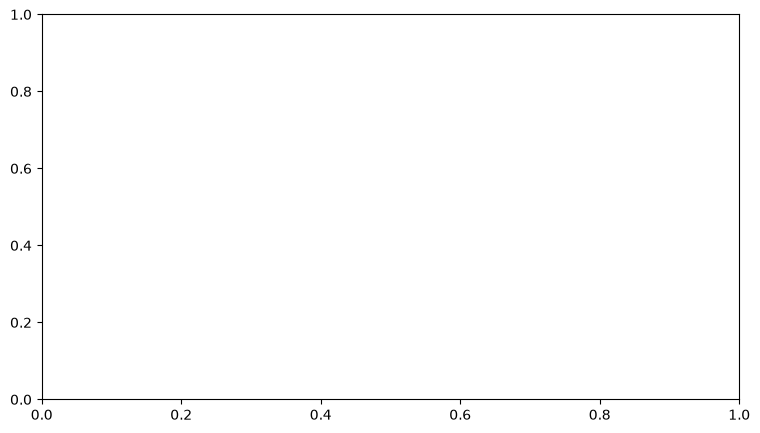

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for use_wind, grp in df_results.groupby("vent"):
    grp = grp.sort_values("history_days")
    ax.plot(grp["history_days"], grp["capture_vs_oracle"] * 100, marker="o",
            label=f"avec vent" if use_wind else "sans vent")
ax.set_xlabel("Historique (jours)")
ax.set_ylabel("Capture vs Oracle (%)")
ax.set_title("Gridsearch — history_days × vent (GradientBoosting)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()